In [66]:
import os
import numpy as np
import time
from itertools import product
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from cpg_rbf.cpg_so2 import CPG_SO2
from cpg_rbf.rbf import RBF
from cpg_rbf.cpg_so2 import CPG_LOCO
from cpg_rbf.dual_learner import DIL

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [67]:
from scipy.interpolate import interp1d
# resample target
def resample_cycle(cycle, num_points):
    """Resamples a gait cycle to have a fixed number of points using interpolation."""
    original_indices = np.linspace(0, 1, len(cycle))  # original indices based on the length of the cycle
    new_indices = np.linspace(0, 1, num_points)  # new indices to match the desired number of points
    interpolation_function = interp1d(original_indices, cycle, kind='linear')  # interpolate the data
    return interpolation_function(new_indices)  # return the resampled cycle

In [68]:
rbf = RBF()
cpg = CPG_SO2()

 


target_length = 10000

# It would be centerize the kernel first
cpg_one_cycle = cpg.generate_cpg_one_cycle(0.05)       # lowest phi value
out0_cpg_one_cycle = cpg_one_cycle['out0_cpg_one_cycle'][:] # Use full cycle of CPG
out1_cpg_one_cycle = cpg_one_cycle['out1_cpg_one_cycle'][:] # Use full cycle of CPG
cpg_cycle_length = len(out0_cpg_one_cycle)
rbf_kernels = rbf.construct_kernels_with_cpg_one_cycle(out0_cpg_one_cycle, out1_cpg_one_cycle, cpg_cycle_length) # construct kernels with cpg one cycle

imitated_weights = np.load('imitated_diving_beetle_walk_forward_weights.npz') # load emtpy weights for initialization

# swimming pattern weights

imitated_weights_swimming_forward 	= np.load('imitated_diving_beetle_swim_forward_weights.npz')
imitated_weights_swimming_back 		= np.load('imitated_diving_beetle_swim_backward_weights.npz')
imitated_weights_swimming_turning 	= np.load('imitated_diving_beetle_swim_turning_weights.npz')
imitated_weights_swimming_cross 	= np.load('imitated_diving_beetle_swim_crossing_weights.npz')

# walking pattern weights
imitated_weights_walking 			= np.load('imitated_diving_beetle_walk_forward_weights.npz')

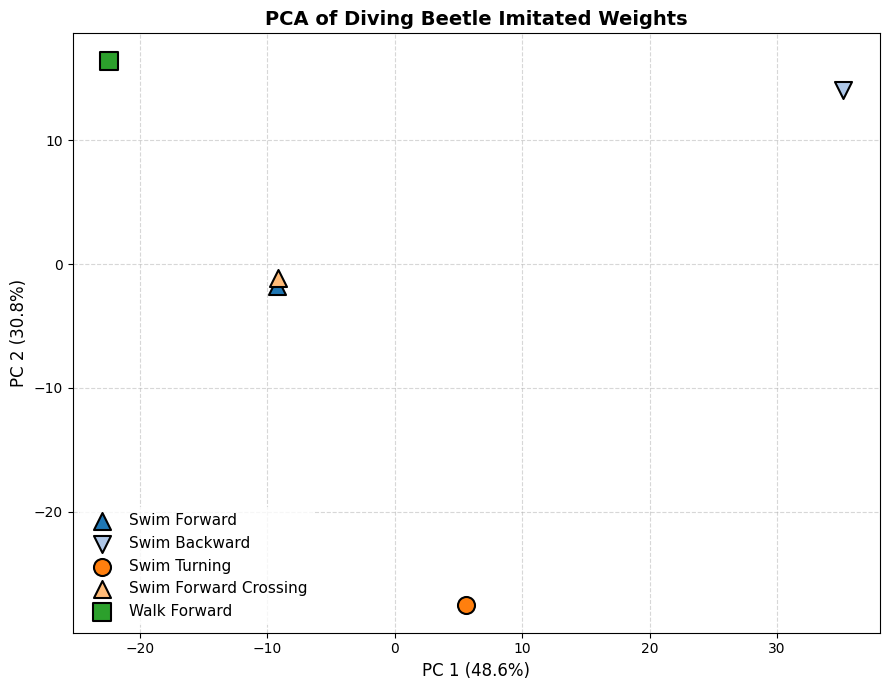

In [69]:

# 1. Define the files and their metadata for plotting
weight_files = {
    'Swim Forward': {
        'filename': 'imitated_diving_beetle_swim_forward_weights.npz',
        'color': '#1f77b4',  # Blue shades for swimming
        'marker': '^'
    },
    'Swim Backward': {
        'filename': 'imitated_diving_beetle_swim_backward_weights.npz',
        'color': '#aec7e8',
        'marker': 'v'
    },
    'Swim Turning': {
        'filename': 'imitated_diving_beetle_swim_turning_weights.npz',
        'color': '#ff7f0e',
        'marker': 'o'
    },
    'Swim Forward Crossing': {
        'filename': 'imitated_diving_beetle_swim_crossing_weights.npz',
        'color': '#ffbb78',
        'marker': '^'
    },
    'Walk Forward': {
        'filename': 'imitated_diving_beetle_walk_forward_weights.npz',
        'color': '#2ca02c',  # Green for walking
        'marker': 's'        # Square marker to differentiate walking
    }
}

all_features = []
labels = []
colors = []
markers = []

# 2. Load and process the weight files
for label, meta in weight_files.items():
    try:
        with np.load(meta['filename']) as data:
            # Extract and flatten all arrays inside the npz file (e.g., layers, weights, biases)
            # If your npz has a specific key like 'weights', you can use data['weights'] instead.
            flat_components = [data[key].ravel() for key in data.files]
            
            # Combine all layers/biases into one long feature vector
            weight_vector = np.concatenate(flat_components)
            
            # Check if the file contains a single model or multiple samples/epochs
            # (Assuming a single model per file here. If each file has multiple rows/samples, 
            # you would loop through those rows instead)
            all_features.append(weight_vector)
            labels.append(label)
            colors.append(meta['color'])
            markers.append(meta['marker'])
            
    except FileNotFoundError:
        print(f"Warning: {meta['filename']} not found. Skipping...")

# Convert to numpy array
if len(all_features) < 2:
    raise ValueError("Need at least 2 valid weight sets/samples to perform PCA.")

X = np.array(all_features)

# 3. Standardize features (highly recommended for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Perform PCA
# If you have fewer than 3 samples total, set n_components to len(X) - 1
n_components = min(2, X.shape[0]) 
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# 5. Plotting the PCA Space
plt.figure(figsize=(9, 7))

# If we have 2 dimensions to plot
if n_components >= 2:
    for i in range(len(labels)):
        plt.scatter(
            X_pca[i, 0], X_pca[i, 1], 
            color=colors[i], 
            marker=markers[i], 
            s=150,  # Marker size
            edgecolors='black', 
            linewidths=1.5,
            label=labels[i]
        )
    
    plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
    plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
    plt.title('PCA of Diving Beetle Imitated Weights', fontsize=14, fontweight='bold')
    
else:
    # Fallback to 1D plot if there are not enough data points
    for i in range(len(labels)):
        plt.scatter(X_pca[i, 0], np.zeros_like(X_pca[i, 0]), color=colors[i], marker=markers[i], s=150, label=labels[i])
    plt.xlabel('PC 1', fontsize=12)
    plt.title('1D PCA Projection of Weights', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True, facecolor='white', edgecolor='none', fontsize=11)
plt.tight_layout()

# Save and show the plot
# plt.savefig('weights_pca_plot.png', dpi=300)
# plt.show()


## Switching Gaits

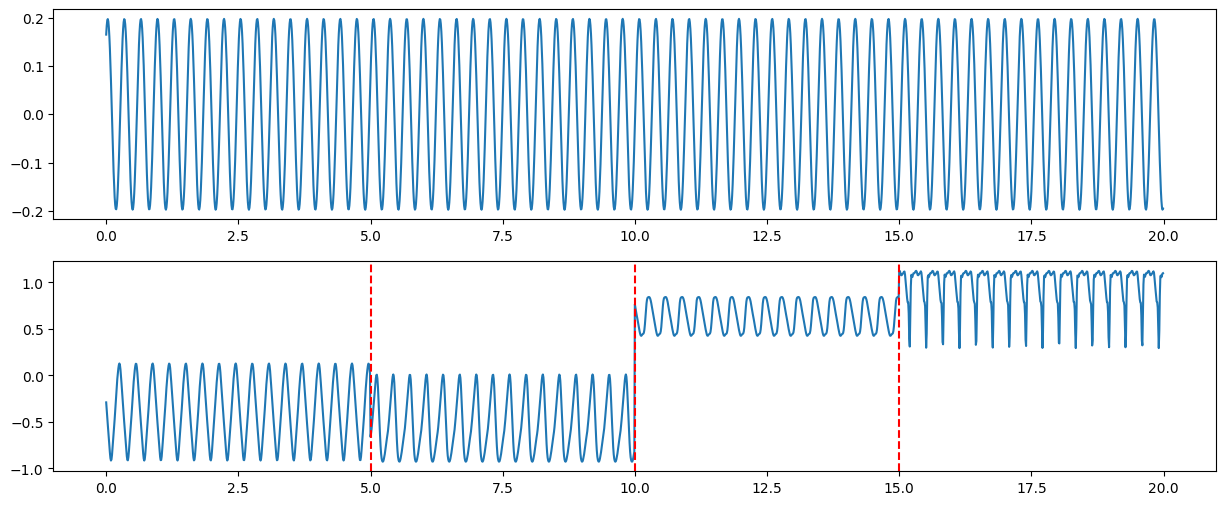

In [70]:
# loop test
cpg_modulated = CPG_LOCO()

# Variables
cpg_output_t = 0
cpg_output_list = []

traj_output_t = 0
traj_output_list = []

time = []

# Simulation setup
duration 	= 20.0  		# seconds
frequency 	= 100  		# Hz
dt 			= 1.0 / frequency  	# 0.01 seconds
total_steps = int(duration * frequency)

for step in range(total_steps):
	sim_time = step * dt

	cpg_output_t = cpg_modulated.modulate_cpg(0.2, 0, 1)

	if sim_time < 5.0:
		traj_output_t = rbf.regenerate_target_traj(cpg_output_t['cpg_output_0'], cpg_output_t['cpg_output_1'], imitated_weights_walking['BR0'])
	elif sim_time < 10.0:
		traj_output_t = rbf.regenerate_target_traj(cpg_output_t['cpg_output_0'], cpg_output_t['cpg_output_1'], imitated_weights_swimming_forward['BR0'])
	elif sim_time < 15.0:
		traj_output_t = rbf.regenerate_target_traj(cpg_output_t['cpg_output_0'], cpg_output_t['cpg_output_1'], imitated_weights_swimming_turning['BR0'])
	else:
		traj_output_t = rbf.regenerate_target_traj(cpg_output_t['cpg_output_0'], cpg_output_t['cpg_output_1'], imitated_weights_swimming_back['BR0'])
	


	traj_output_list.append(traj_output_t)
	cpg_output_list.append(cpg_output_t['cpg_output_0'])
	time.append(sim_time)




# Figure plots
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=False)

axs[0].plot(time, cpg_output_list)

axs[1].plot(time, traj_output_list)
for pt in [5.0, 10.0, 15.0]:
    # Only apply the label to the first one so it doesn't duplicate in the legend
    lbl = 'Transition Points' if pt == 2.0 else ""
    axs[1].axvline(x=pt, color='r', linestyle='--', label=lbl)


# fig.tight_layout()
# fig.savefig('adaptive_locomotion_trajectory_plot_0.png', dpi=300)


traj_output_switch_list = traj_output_list.copy()

## Change Gaits

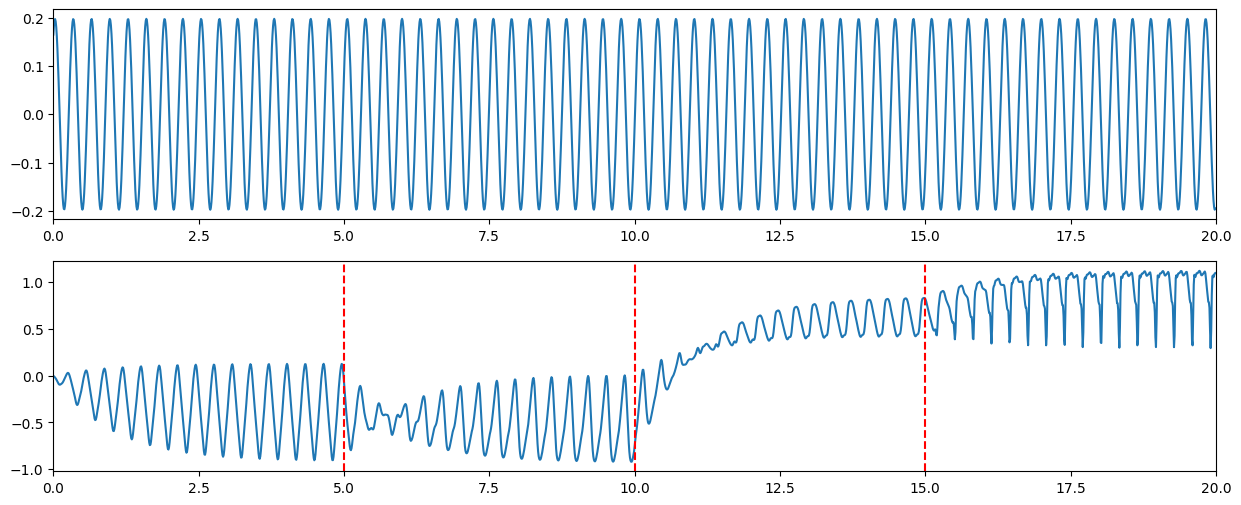

In [71]:
# loop test
cpg_modulated = CPG_LOCO()

# Variables
cpg_output_t = 0
cpg_output_list = []

traj_output_t = 0
traj_output_list = []

rbf_weight_prev 	= np.zeros_like(imitated_weights_walking['BR0'])  
rbf_weight_t 		= np.zeros_like(imitated_weights_walking['BR0'])
rbf_weight_target 	= np.zeros_like(imitated_weights_walking['BR0'])
rbf_weight_list 	= []
time = []

# Simulation setup
duration 	= 20.0  		# seconds
frequency 	= 100  		# Hz
dt 			= 1.0 / frequency  	# 0.01 seconds
total_steps = int(duration * frequency)

for step in range(total_steps):
	sim_time = step * dt

	cpg_output_t = cpg_modulated.modulate_cpg(0.2, 0, 1)

		
	
	if sim_time < 5.0:
		rbf_weight_target 	= imitated_weights_walking['BR0']
	elif sim_time < 10.0:
		rbf_weight_target 	= imitated_weights_swimming_forward['BR0']
	elif sim_time < 15.0:
		rbf_weight_target 	= imitated_weights_swimming_turning['BR0']
	elif sim_time < 20.0:
		rbf_weight_target 	= imitated_weights_swimming_back['BR0']
	


	
	rbf_weight_t = rbf_weight_prev + (rbf_weight_target - rbf_weight_prev) * 0.01  # Smooth transition
	
	
	traj_output_t = rbf.regenerate_target_traj(cpg_output_t['cpg_output_0'], cpg_output_t['cpg_output_1'], rbf_weight_t)


	rbf_weight_prev = rbf_weight_t

	rbf_weight_list.append(rbf_weight_t)
	traj_output_list.append(traj_output_t)
	cpg_output_list.append(cpg_output_t['cpg_output_0'])
	time.append(sim_time)




# Figure plots
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=False)

axs[0].plot(time, cpg_output_list)

axs[1].plot(time, traj_output_list)
for pt in [5.0, 10.0, 15.0]:
    # Only apply the label to the first one so it doesn't duplicate in the legend
    lbl = 'Transition Points' if pt == 2.0 else ""
    axs[1].axvline(x=pt, color='r', linestyle='--', label=lbl)

axs[0].set_xlim(0, duration)
axs[1].set_xlim(0, duration)

# fig.tight_layout()
# fig.savefig('adaptive_locomotion_trajectory_plot_1.png', dpi=300)

traj_output_no_mask_list = traj_output_list.copy()

### Weight Change PCA plot

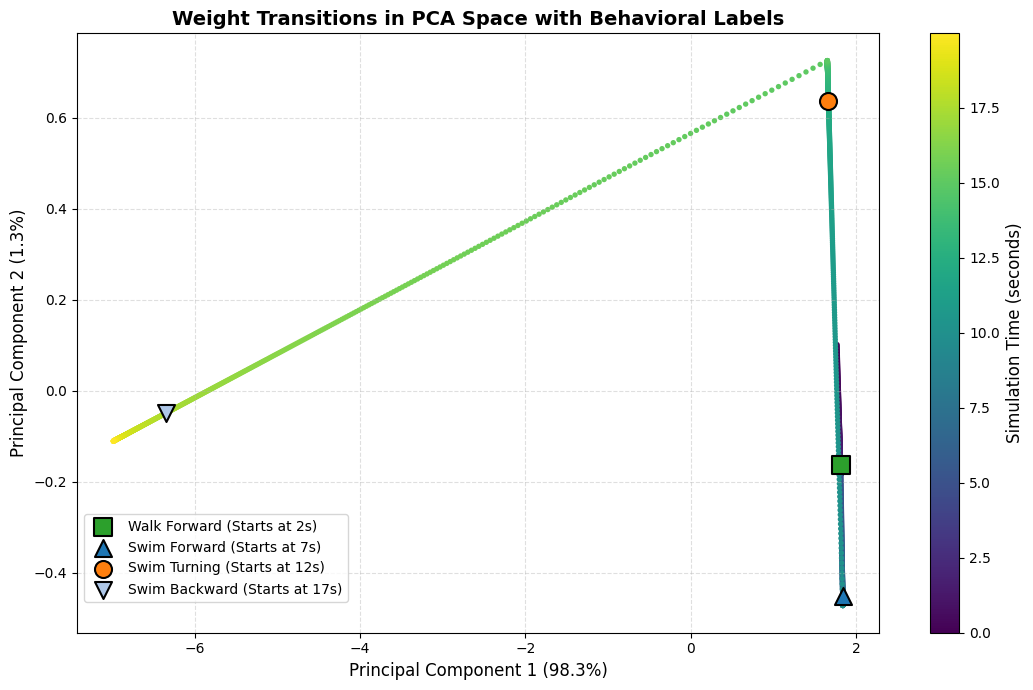

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Your custom labels and styles
weight_files = {
    'Swim Forward': {
        'color': '#1f77b4',
        'marker': '^'
    },
    'Swim Backward': {
        'color': '#aec7e8',
        'marker': 'v'
    },
    'Swim Turning': {
        'color': '#ff7f0e',
        'marker': 'o'
    },
    'Swim Forward Crossing': {
        'color': '#ffbb78',
        'marker': '^'
    },
    'Walk Forward': {
        'color': '#2ca02c',
        'marker': 's'
    }
}

# 2. Convert the list of weight vectors into a 2D array
rbf_weights_matrix = np.array(rbf_weight_list)

# 3. Fit and transform the weights using PCA
pca = PCA(n_components=2)
rbf_pca = pca.fit_transform(rbf_weights_matrix)

# 4. Create the scatter plot
plt.figure(figsize=(11, 7))

# Plot EVERY point, using time as the color map to show chronological progression
scatter = plt.scatter(
    rbf_pca[:, 0], 
    rbf_pca[:, 1], 
    c=time, 
    cmap='viridis',     # 'viridis' transitions from purple -> blue -> green -> yellow
    s=15,               # Size of individual points
    alpha=1.0,          # Slight transparency so overlapping points show density
    edgecolors='none'
)

# 5. Explicitly mark the phase transitions using your custom dictionary
time_np = np.array(time)

# Map the transition times to their corresponding target behavior labels
transitions = [
    (2.5, 'Walk Forward'),
    (7.5, 'Swim Forward'),
    (12.5, 'Swim Turning'),
    (17.5, 'Swim Backward')
]

for t, label in transitions:
    # Find the closest index in the time array to our target transition time
    idx = np.abs(time_np - t).argmin()
    
    # Fetch style from dictionary
    color = weight_files[label]['color']
    marker = weight_files[label]['marker']
    
    # Highlight this specific transition point
    plt.scatter(
        rbf_pca[idx, 0], rbf_pca[idx, 1], 
        color=color, 
        edgecolors='black', # Black border makes the custom color pop against the gradient
        linewidths=1.5,
        s=150, 
        marker=marker, 
        zorder=5, 
        label=f"{label} (Starts at {int(t)}s)"
    )

# # Optional: Add 'Walk Forward' to the legend just so the dictionary is fully represented
# plt.scatter([], [], color=weight_files['Walk Forward']['color'], 
#             marker=weight_files['Walk Forward']['marker'], 
#             s=150, edgecolors='black', label="Walk Forward (Inactive)")

# 6. Aesthetics, Labels, and Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Simulation Time (seconds)', fontsize=12)

plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('Weight Transitions in PCA Space with Behavioral Labels', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)

# Place legend outside the plot so it doesn't overlap the trajectory
plt.legend(frameon=True, facecolor='white', loc='center left', bbox_to_anchor=(0, 0.125), fontsize=10)
plt.tight_layout()

# Save the plot
# plt.savefig('rbf_weights_pca_hybrid_labels.png', dpi=300, bbox_inches='tight')
# plt.show()

In [73]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# 1. Custom labels and styles 
# Note: Plotly 3D scatter markers differ from Matplotlib. 
# Mapped to Plotly 3D supported symbols: circle, square, diamond, cross, x
weight_files = {
    'Swim Forward': {
        'color': '#1f77b4',
        'marker': 'diamond'  # Replaced '^'
    },
    'Swim Backward': {
        'color': '#aec7e8',
        'marker': 'cross'    # Replaced 'v'
    },
    'Swim Turning': {
        'color': '#ff7f0e',
        'marker': 'circle'   # Replaced 'o'
    },
    'Swim Forward Crossing': {
        'color': '#ffbb78',
        'marker': 'diamond'  # Replaced '^'
    },
    'Walk Forward': {
        'color': '#2ca02c',
        'marker': 'square'   # Replaced 's'
    }
}

# 2. Convert the list of weight vectors into a 2D array
rbf_weights_matrix = np.array(rbf_weight_list)

# 3. Fit and transform the weights using PCA (3 Components for 3D)
pca = PCA(n_components=3)
rbf_pca = pca.fit_transform(rbf_weights_matrix)

# 4. Initialize Plotly figure
fig = go.Figure()

# Plot EVERY point, using time as the color scale to show chronological progression
fig.add_trace(go.Scatter3d(
    x=rbf_pca[:, 0], 
    y=rbf_pca[:, 1], 
    z=rbf_pca[:, 2],
    mode='markers',
    marker=dict(
        size=4,
        color=time,                # Color driven by time array
        colorscale='Viridis',      # Viridis color gradient
        opacity=0.8,
        colorbar=dict(title="Simulation Time (s)", x=1.05), # Colorbar on the right
    ),
    name='Weight Trajectory',
    showlegend=False               # Hide from legend to keep it clean
))

# 5. Explicitly mark the phase transitions
time_np = np.array(time)

transitions = [
    (2.5, 'Walk Forward'),
    (7.5, 'Swim Forward'),
    (12.5, 'Swim Turning'),
    (17.5, 'Swim Backward')
]

for t, label in transitions:
    # Find the closest index in the time array to our target transition time
    idx = np.abs(time_np - t).argmin()
    
    # Fetch style from dictionary
    color = weight_files[label]['color']
    marker_symbol = weight_files[label]['marker']
    
    # Highlight this specific transition point
    fig.add_trace(go.Scatter3d(
        x=[rbf_pca[idx, 0]], 
        y=[rbf_pca[idx, 1]], 
        z=[rbf_pca[idx, 2]],
        mode='markers',
        marker=dict(
            size=12,               # Larger size for the key points
            color=color, 
            symbol=marker_symbol,
            line=dict(color='black', width=2) # Black border for contrast
        ),
        name=f"{label} (Starts at {int(t)}s)"
    ))

# 6. Aesthetics, Labels, and Layout
evr = pca.explained_variance_ratio_ * 100

fig.update_layout(
    title=dict(text='3D Weight Transitions in PCA Space', font=dict(size=18, family="Arial")),
    scene=dict(
        xaxis_title=f'PC 1 ({evr[0]:.1f}%)',
        yaxis_title=f'PC 2 ({evr[1]:.1f}%)',
        zaxis_title=f'PC 3 ({evr[2]:.1f}%)',
        xaxis=dict(backgroundcolor="rgba(240, 240, 240, 0.8)"),
        yaxis=dict(backgroundcolor="rgba(240, 240, 240, 0.8)"),
        zaxis=dict(backgroundcolor="rgba(240, 240, 240, 0.8)")
    ),
    legend=dict(
        title="Behavioral Targets",
        yanchor="top",
        y=0.9,
        xanchor="left",
        x=0.05,
        bgcolor="rgba(255, 255, 255, 0.8)", # Slight white background behind legend
        bordercolor="Black",
        borderwidth=1
    ),
    margin=dict(l=0, r=0, b=0, t=50) # Tighter margins for 3D plot
)

# Render the interactive plot in the browser / notebook
fig.show()

# Optional: Save as an interactive HTML file you can open in Chrome/Edge
fig.write_html('rbf_weights_pca_3d.html')

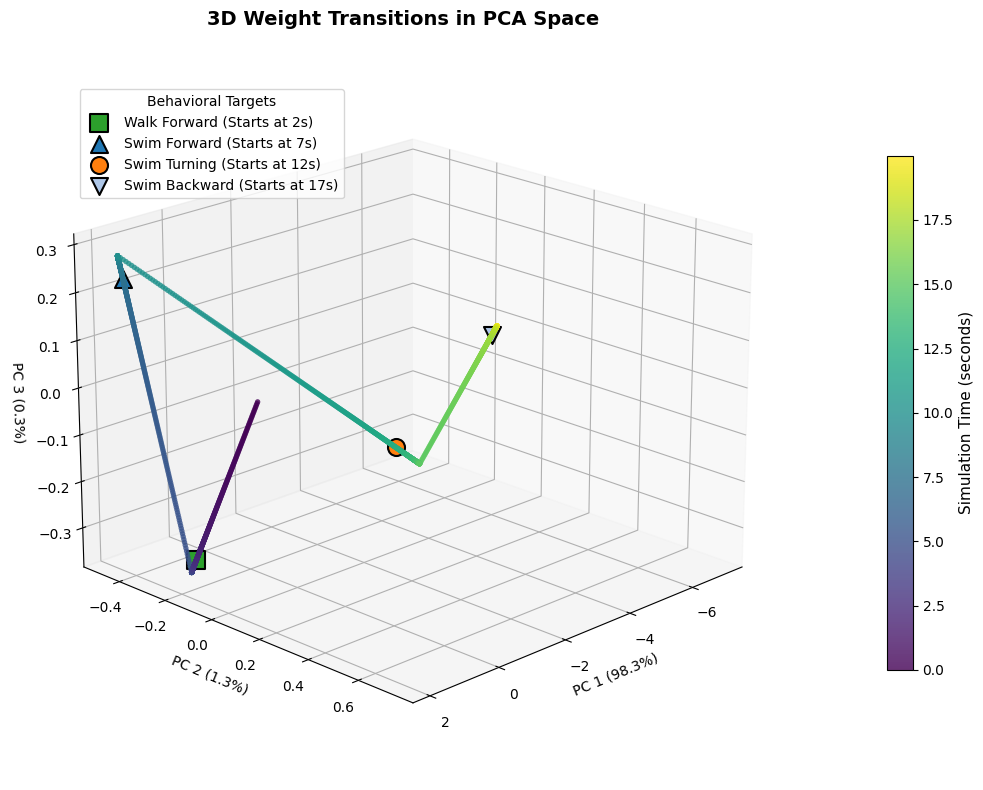

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. Custom labels and styles 
# Reverted back to Matplotlib's native marker symbols
weight_files = {
    'Swim Forward': {
        'color': '#1f77b4',
        'marker': '^'
    },
    'Swim Backward': {
        'color': '#aec7e8',
        'marker': 'v'
    },
    'Swim Turning': {
        'color': '#ff7f0e',
        'marker': 'o'
    },
    'Swim Forward Crossing': {
        'color': '#ffbb78',
        'marker': '^'
    },
    'Walk Forward': {
        'color': '#2ca02c',
        'marker': 's'
    }
}

# 2. Convert the list of weight vectors into a 2D array
rbf_weights_matrix = np.array(rbf_weight_list)

# 3. Fit and transform the weights using PCA (3 Components for 3D)
pca = PCA(n_components=3)
rbf_pca = pca.fit_transform(rbf_weights_matrix)

# 4. Initialize Matplotlib 3D figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot EVERY point, using time as the color scale to show chronological progression
scatter = ax.scatter(
    rbf_pca[:, 0], 
    rbf_pca[:, 1], 
    rbf_pca[:, 2],
    c=time,                 # Color driven by time array
    cmap='viridis',         # Viridis color gradient
    s=15,                   # Point size
    alpha=0.8,
    edgecolors='none'
)

# Add the colorbar for the time gradient
cbar = plt.colorbar(scatter, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Simulation Time (seconds)', fontsize=11)

# 5. Explicitly mark the phase transitions
time_np = np.array(time)

transitions = [
    (2.5, 'Walk Forward'),
    (7.5, 'Swim Forward'),
    (12.5, 'Swim Turning'),
    (17.5, 'Swim Backward')
]

for t, label in transitions:
    # Find the closest index in the time array to our target transition time
    idx = np.abs(time_np - t).argmin()
    
    # Fetch style from dictionary
    color = weight_files[label]['color']
    marker_symbol = weight_files[label]['marker']
    
    # Highlight this specific transition point
    ax.scatter(
        rbf_pca[idx, 0], 
        rbf_pca[idx, 1], 
        rbf_pca[idx, 2],
        color=color,
        marker=marker_symbol,
        s=150,                             # Larger size for key points
        edgecolors='black',                # Black border for contrast
        linewidths=1.5,
        alpha=1.0,
        zorder=5,                          # Try to force it to the front
        label=f"{label} (Starts at {int(t)}s)"
    )

# 6. Aesthetics, Labels, and Layout
evr = pca.explained_variance_ratio_ * 100

ax.set_xlabel(f'PC 1 ({evr[0]:.1f}%)', fontsize=10)
ax.set_ylabel(f'PC 2 ({evr[1]:.1f}%)', fontsize=10)
ax.set_zlabel(f'PC 3 ({evr[2]:.1f}%)', fontsize=10)
ax.set_title('3D Weight Transitions in PCA Space', fontsize=14, fontweight='bold', pad=15)

# Tweak the viewing angle (Elevation, Azimuth) for better initial visibility
ax.view_init(elev=20, azim=45) 

# Place the legend outside the 3D plot area to avoid clutter
ax.legend(
    title="Behavioral Targets",
    frameon=True, 
    facecolor='white', 
    loc='upper left', 
    bbox_to_anchor=(0.05, 0.95), 
    fontsize=10
)

plt.tight_layout()

# Save and render
# plt.savefig('rbf_weights_pca_3d_matplotlib.png', dpi=300, bbox_inches='tight')
plt.show()

## Change Gaits (Kernel Masking)

### Kernel plot

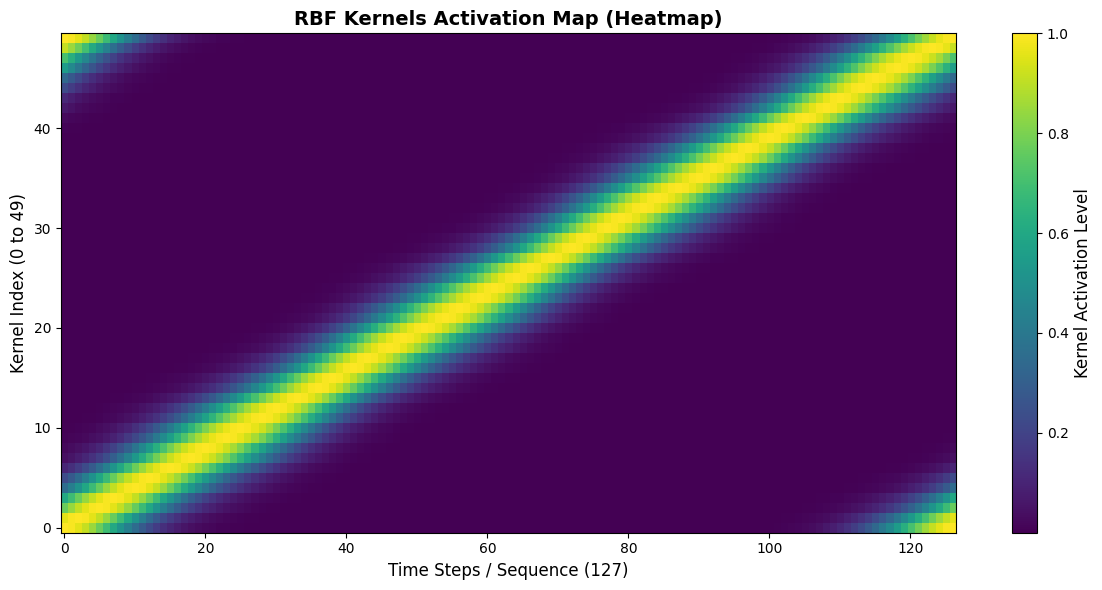

In [75]:
# Assuming 'rbf_kernels' is your (50, 127) numpy array
plt.figure(figsize=(12, 6))

# imshow is perfect for 2D matrices
# aspect='auto' ensures it stretches nicely to fit the 12x6 figure
# origin='lower' puts kernel 0 at the bottom of the y-axis
im = plt.imshow(rbf_kernels, aspect='auto', cmap='viridis', origin='lower')

# Add a colorbar to show the scale (0.0 to 1.0)
cbar = plt.colorbar(im)
cbar.set_label('Kernel Activation Level', fontsize=12)

plt.xlabel('Time Steps / Sequence (127)', fontsize=12)
plt.ylabel('Kernel Index (0 to 49)', fontsize=12)
plt.title('RBF Kernels Activation Map (Heatmap)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

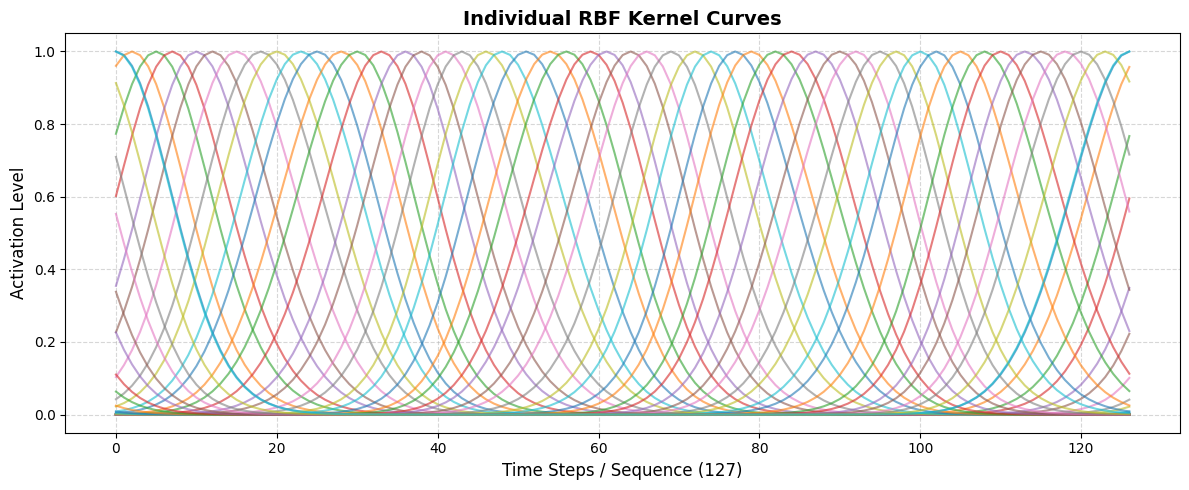

In [76]:

plt.figure(figsize=(12, 5))

# Loop through each of the 50 kernels and plot its 127 values
# We use alpha=0.6 to make the lines slightly transparent so overlapping curves are visible
for i in range(rbf_kernels.shape[0]):
    plt.plot(rbf_kernels[i, :], alpha=0.6, linewidth=1.5)

plt.xlabel('Time Steps / Sequence (127)', fontsize=12)
plt.ylabel('Activation Level', fontsize=12)
plt.title('Individual RBF Kernel Curves', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Optional: Set y-limits if you know your activations are strictly between 0 and 1
plt.ylim(-0.05, 1.05) 

plt.tight_layout()
plt.show()

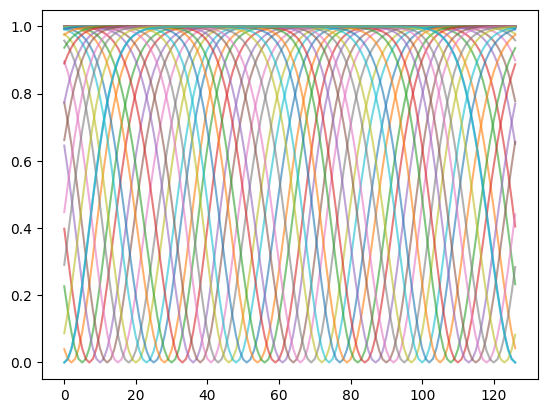

In [77]:
new_kernel = []
for i in range(rbf_kernels.shape[0]):
    new_kernel.append(1 - rbf_kernels[i, :])
    plt.plot(new_kernel[i], alpha=0.6, linewidth=1.5)

### Loop

(50,)


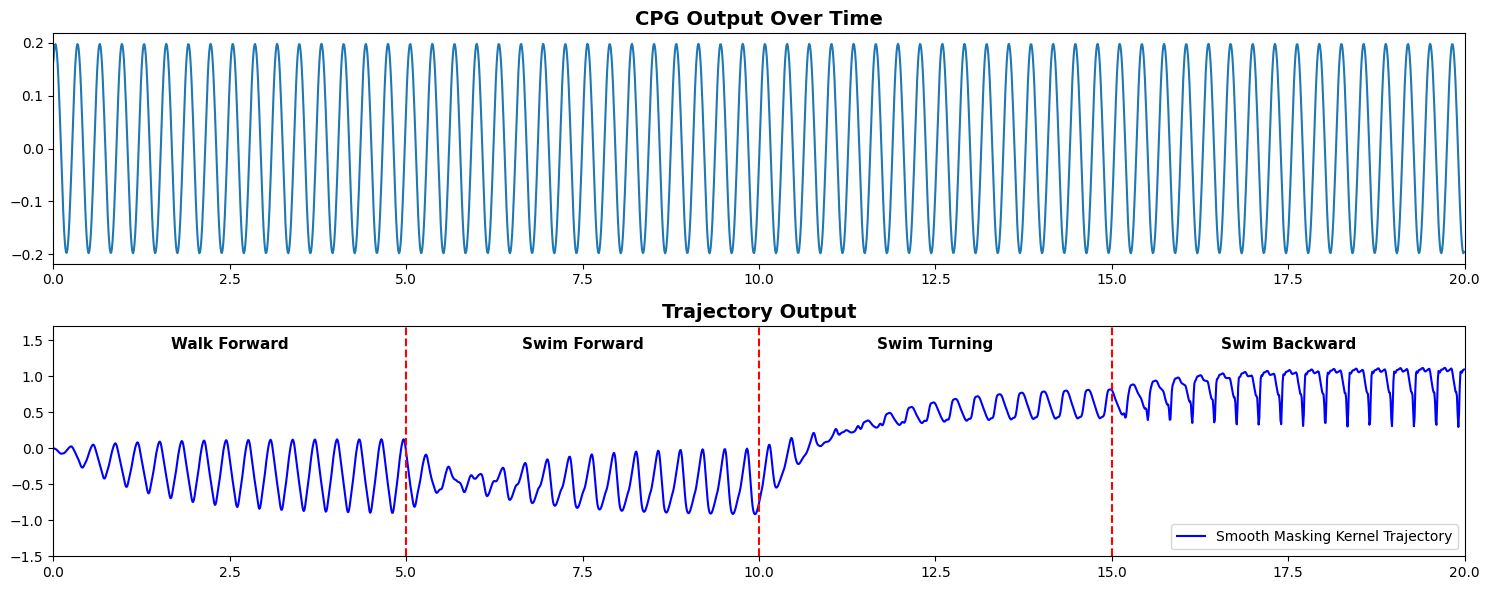

In [ ]:
# loop test
cpg_modulated = CPG_LOCO()

# Variables
cpg_output_t = 0
cpg_output_list = []

traj_output_t = 0
traj_output_list = []

traj_output2_t = 0
traj_output2_list = []

rbf_weight_t 		= np.zeros_like(imitated_weights_walking['BR0'])
rbf_weight_prev 	= np.zeros_like(imitated_weights_walking['BR0']) 

rbf_weight_t2 		= np.zeros_like(imitated_weights_walking['BR0'])
rbf_weight_vel_t2 	= np.zeros_like(imitated_weights_walking['BR0'])
rbf_weight_prev2 	= np.zeros_like(imitated_weights_walking['BR0']) 
rbf_weight_vel_prev2 = np.zeros_like(imitated_weights_walking['BR0']) 


rbf_weight_target 	= np.zeros_like(imitated_weights_walking['BR0'])
del_weight_t 		= np.zeros_like(imitated_weights_walking['BR0'])
print(np.shape(rbf_weight_prev))
rbf_weight_list 	= []
time = []

# Simulation setup
duration 	= 20.0  		# seconds
frequency 	= 100  		# Hz
dt 			= 1.0 / frequency  	# 0.01 seconds
total_steps = int(duration * frequency)

for step in range(total_steps):
	sim_time = step * dt


		
	
	if sim_time < 5.0:
		rbf_weight_target 	= imitated_weights_walking['BR0']
	elif sim_time < 10.0:
		rbf_weight_target 	= imitated_weights_swimming_forward['BR0']
	elif sim_time < 15.0:
		rbf_weight_target 	= imitated_weights_swimming_turning['BR0']
	elif sim_time < 20.0:
		rbf_weight_target 	= imitated_weights_swimming_back['BR0']
	




	cpg_output_t = cpg_modulated.modulate_cpg(0.2, 0, 1)
	traj_output_t, rbf_weight_t = rbf.regenerate_smooth_gated_traj(
		cpg_output_t['cpg_output_0'], 
		cpg_output_t['cpg_output_1'], 
		rbf_weight_prev,
		rbf_weight_target,
		base_alpha=0.01  
	)
	rbf_weight_prev = rbf_weight_t

	# traj_output2_t, rbf_weight_t2, rbf_weight_vel_t2 = rbf.regenerate_second_order_gated_traj(
    #     cpg_output_t['cpg_output_0'], 
    #     cpg_output_t['cpg_output_1'], 
    #     rbf_weight_prev2,
    #     rbf_weight_vel_prev2,
    #     rbf_weight_target,
    #     omega=6,   # Tweak this to adjust target convergence speed
    #     dt=dt        # 0.01 for 100 Hz
    # )

	# rbf_weight_prev2 = rbf_weight_t2
	# rbf_weight_vel_prev2 = rbf_weight_vel_t2


	rbf_weight_list.append(rbf_weight_t)
	traj_output_list.append(traj_output_t)
	cpg_output_list.append(cpg_output_t['cpg_output_0'])
	time.append(sim_time)




# Figure plots
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=False)

axs[0].plot(time, cpg_output_list)
axs[0].set_title('CPG Output Over Time', fontsize=14, fontweight='bold')

axs[1].set_title('Trajectory Output', fontsize=14, fontweight='bold')
axs[1].plot(time, traj_output_list, label='Smooth Masking Kernel Trajectory', color='blue')
for pt in [5.0, 10.0, 15.0]:
    # Only apply the label to the first one so it doesn't duplicate in the legend
    lbl = 'Transition Points' if pt == 2.0 else ""
    axs[1].axvline(x=pt, color='r', linestyle='--', label=lbl)

regions = [
    (2.5, 'Walk Forward'),
    (7.5, 'Swim Forward'),
    (12.5, 'Swim Turning'),
    (17.5, 'Swim Backward')
]

for x_pos, region_name in regions:
    axs[1].text(
        x=x_pos, 
        y=0.95, # 95% of the way to the top of the plot
        s=region_name, 
        transform=axs[1].get_xaxis_transform(), # x is data units, y is relative (0 to 1)
        ha='center', # Horizontally center the text at x_pos
        va='top',    # Align the top of the text to y=0.95
        fontsize=11, 
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2') # Adds a slight white background for readability
    )
axs[0].set_xlim(0, duration)

axs[1].set_xlim(0, duration)
axs[1].set_ylim(-1.5, 1.7)

axs[1].legend(loc='lower right', fontsize=10)
fig.tight_layout()
# fig.savefig('adaptive_locomotion_trajectory_plot_2.png', dpi=300)

## Plot Compare

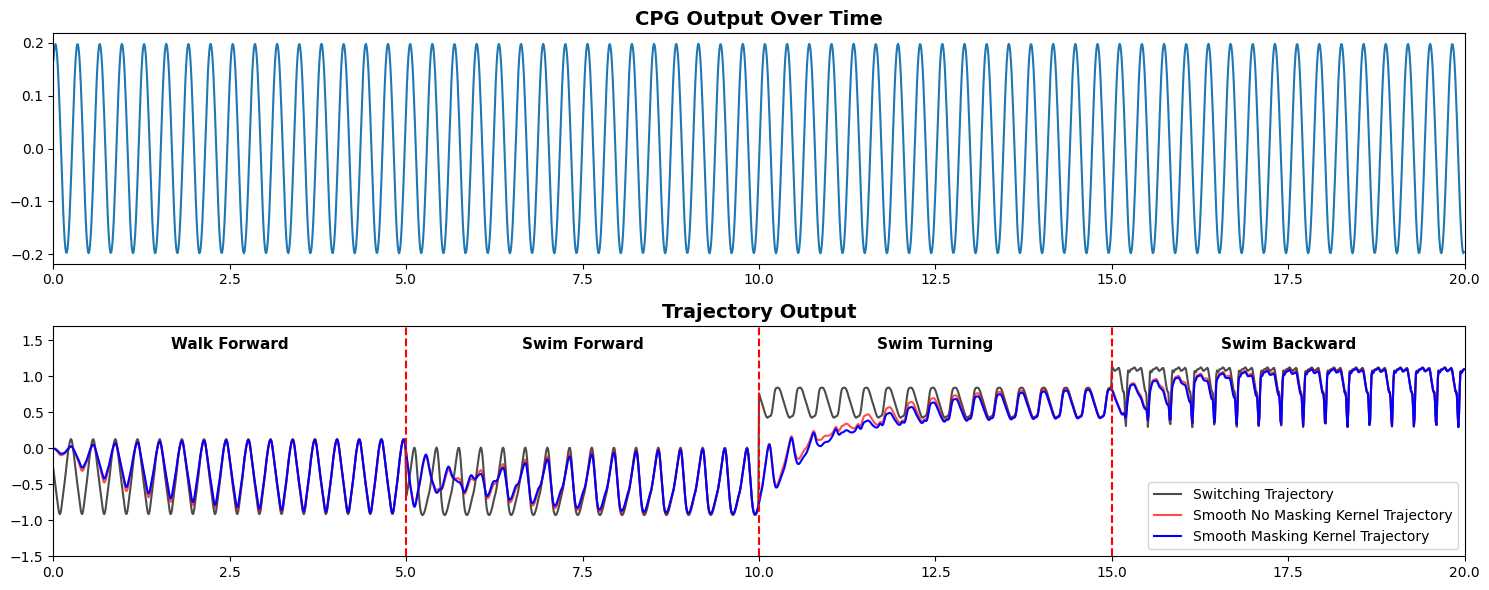

In [79]:



# Figure plots
fig, axs = plt.subplots(2, 1, figsize=(15, 6), sharex=False)

axs[0].plot(time, cpg_output_list)
axs[0].set_title('CPG Output Over Time', fontsize=14, fontweight='bold')

axs[1].set_title('Trajectory Output', fontsize=14, fontweight='bold')

axs[1].plot(time, traj_output_switch_list, label='Switching Trajectory', color='black', alpha=0.7)
axs[1].plot(time, traj_output_no_mask_list, label='Smooth No Masking Kernel Trajectory', color='red', alpha=0.7)
axs[1].plot(time, traj_output_list, label='Smooth Masking Kernel Trajectory', color='blue')
for pt in [5.0, 10.0, 15.0]:
    # Only apply the label to the first one so it doesn't duplicate in the legend
    lbl = 'Transition Points' if pt == 2.0 else ""
    axs[1].axvline(x=pt, color='r', linestyle='--', label=lbl)

regions = [
    (2.5, 'Walk Forward'),
    (7.5, 'Swim Forward'),
    (12.5, 'Swim Turning'),
    (17.5, 'Swim Backward')
]

for x_pos, region_name in regions:
    axs[1].text(
        x=x_pos, 
        y=0.95, # 95% of the way to the top of the plot
        s=region_name, 
        transform=axs[1].get_xaxis_transform(), # x is data units, y is relative (0 to 1)
        ha='center', # Horizontally center the text at x_pos
        va='top',    # Align the top of the text to y=0.95
        fontsize=11, 
        fontweight='bold',
        color='black',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2') # Adds a slight white background for readability
    )
axs[0].set_xlim(0, duration)

axs[1].set_xlim(0, duration)
axs[1].set_ylim(-1.5, 1.7)

axs[1].legend(loc='lower right', fontsize=10)
fig.tight_layout()
# fig.savefig('adaptive_locomotion_trajectory_plot_2.png', dpi=300)